In [1]:
import collect_results
import importlib


importlib.reload(collect_results)

<module 'collect_results' from '/nfs/scistore19/alistgrp/eiofinov/PanzaMail-snippets/scripts/collect_results.py'>

In [2]:
 importlib.reload(collect_results)
 df = collect_results.collect_results()

there are 148 files


In [3]:
df = df[df.user == 'snippets2']

In [4]:
df

,run_name,anonymous,user,model,precision,batch_size,finetuning,lora_rank,learning_rate,epochs,...,ROUGE_rouge1_recall,ROUGE_rouge2_fmeasure,ROUGE_rouge2_precision,ROUGE_rouge2_recall,ROUGE_rougeL_fmeasure,ROUGE_rougeL_precision,ROUGE_rougeL_recall,ROUGE_rougeLsum_fmeasure,ROUGE_rougeLsum_precision,ROUGE_rougeLsum_recall
0,panza_snippets2-Qwen3.5-9B-bf16-bs6-fft-lr3.6e...,False,snippets2,Qwen3.5-9B,bf16,6,fft,None,0.000004,4,...,0.740049,0.528185,0.537708,0.522330,0.668501,0.680478,0.661107,0.668501,0.680478,0.661107
1,panza_snippets2-Qwen3.5-9B-bf16-bs4-fft-lr1.1e...,False,snippets2,Qwen3.5-9B,bf16,4,fft,None,0.000011,4,...,0.730776,0.534542,0.552372,0.521722,0.678027,0.700364,0.661885,0.678027,0.700364,0.661885
3,panza_snippets2-Qwen3.5-9B-bf16-bs4-fft-lr1.1e...,False,snippets2,Qwen3.5-9B,bf16,4,fft,None,0.000011,5,...,0.727968,0.522348,0.535981,0.513793,0.665380,0.682071,0.654871,0.665380,0.682071,0.654871
4,panza_snippets2-Qwen3.5-9B-bf16-bs4-fft-lr2e-0...,False,snippets2,Qwen3.5-9B,bf16,4,fft,None,0.000020,4,...,0.731064,0.510177,0.517954,0.507090,0.657495,0.666337,0.654471,0.657495,0.666337,0.654471
5,panza_snippets2-Qwen3.5-9B-bf16-bs4-fft-lr6.3e...,False,snippets2,Qwen3.5-9B,bf16,4,fft,None,0.000006,4,...,0.732824,0.506006,0.515081,0.501834,0.661009,0.672590,0.655662,0.661009,0.672590,0.655662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,panza_snippets2-Qwen3.5-4B-bf16-bs4-fft-lr0.00...,False,snippets2,Qwen3.5-4B,bf16,4,fft,None,0.000110,4,...,0.529858,0.275479,0.270542,0.309413,0.392197,0.386283,0.449425,0.392197,0.386283,0.449425
143,panza_snippets2-Qwen3.5-0.8B-bf16-bs4-fft-lr0....,False,snippets2,Qwen3.5-0.8B,bf16,4,fft,None,0.000110,4,...,0.544218,0.284957,0.298273,0.306192,0.398958,0.416768,0.436754,0.398958,0.416768,0.436754
144,panza_snippets2-Qwen3.5-0.8B-bf16-bs4-fft-lr0....,False,snippets2,Qwen3.5-0.8B,bf16,4,fft,None,0.000110,3,...,0.509738,0.287674,0.323472,0.290451,0.412431,0.463315,0.418904,0.412431,0.463315,0.418904
145,panza_snippets2-Qwen3.5-9B-bf16-bs4-fft-lr6.3e...,False,snippets2,Qwen3.5-9B,bf16,4,fft,None,0.000006,5,...,0.530871,0.261160,0.265466,0.279144,0.313442,0.316216,0.339312,0.313442,0.316216,0.339312


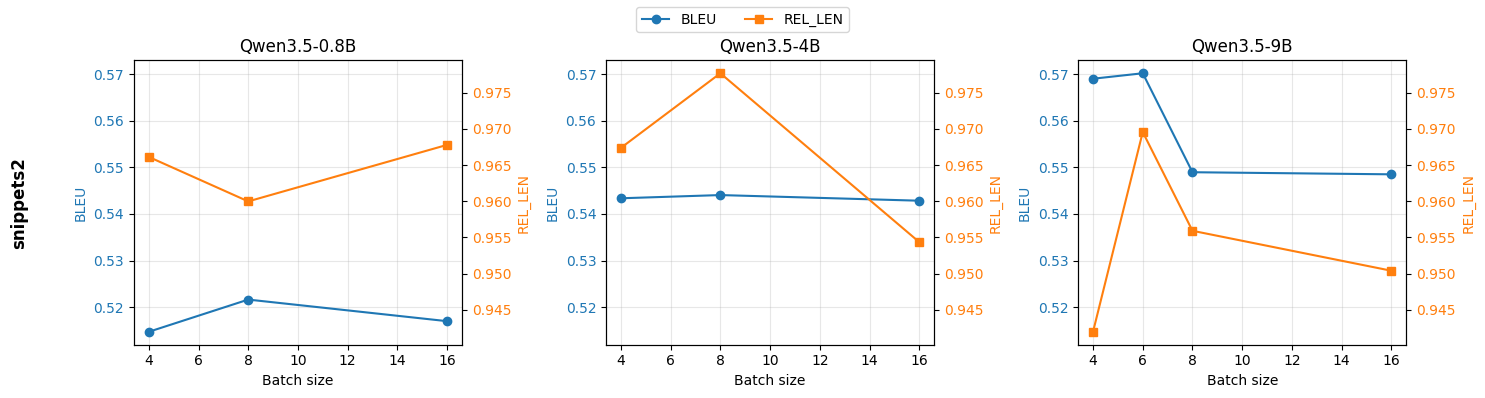

In [5]:
import matplotlib.pyplot as plt
importlib.reload(collect_results)

plot_df = df[["user", "model", "batch_size", "BLEU", "NUM_WORDS", "NUM_WORDS_GOLDEN"]].dropna().copy()
plot_df["REL_LEN"] = plot_df["NUM_WORDS"] / plot_df["NUM_WORDS_GOLDEN"].where(
    plot_df["NUM_WORDS_GOLDEN"] != 0
)

best_by_batch_size = (
    plot_df.loc[
        plot_df.groupby(["user", "model", "batch_size"])["BLEU"].idxmax()
    ]
    .sort_values(["user", "model", "batch_size"])
    .reset_index(drop=True)
)
summary = best_by_batch_size

if summary.empty:
    print("No rows available to plot.")
else:
    def padded_limits(values, pad_fraction=0.05):
        values = values.dropna()
        if values.empty:
            return None
        lower = values.min()
        upper = values.max()
        if lower == upper:
            pad = 1.0 if lower == 0 else abs(lower) * pad_fraction
        else:
            pad = (upper - lower) * pad_fraction
        return lower - pad, upper + pad

    users = sorted(summary["user"].unique())
    models = sorted(summary["model"].unique())
    bleu_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "BLEU"])
        for user in users
    }
    rel_len_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "REL_LEN"])
        for user in users
    }
    fig, axes = plt.subplots(
        len(users),
        len(models),
        figsize=(5 * len(models), 4 * len(users)),
        squeeze=False,
    )
    legend_lines = None

    for row_idx, user in enumerate(users):
        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            if row_idx == 0:
                ax.set_title(model)
            if col_idx == 0:
                ax.text(
                    -0.35,
                    0.5,
                    user,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            user_model_df = summary[
                (summary["user"] == user) & (summary["model"] == model)
            ]
            if user_model_df.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="0.5")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            ax_rel = ax.twinx()
            bleu_line = ax.plot(
                user_model_df["batch_size"],
                user_model_df["BLEU"],
                marker="o",
                color="tab:blue",
                label="BLEU",
            )
            rel_len_line = ax_rel.plot(
                user_model_df["batch_size"],
                user_model_df["REL_LEN"],
                marker="s",
                color="tab:orange",
                label="REL_LEN",
            )

            if legend_lines is None:
                legend_lines = bleu_line + rel_len_line

            ax.set_xlabel("Batch size")
            ax.set_ylabel("BLEU", color="tab:blue")
            ax_rel.set_ylabel("REL_LEN", color="tab:orange")
            ax.tick_params(axis="y", labelcolor="tab:blue")
            ax_rel.tick_params(axis="y", labelcolor="tab:orange")
            if bleu_limits[user] is not None:
                ax.set_ylim(*bleu_limits[user])
            if rel_len_limits[user] is not None:
                ax_rel.set_ylim(*rel_len_limits[user])
            ax.grid(True, alpha=0.3)

    if legend_lines is not None:
        fig.legend(legend_lines, [line.get_label() for line in legend_lines], loc="upper center", ncol=2)

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


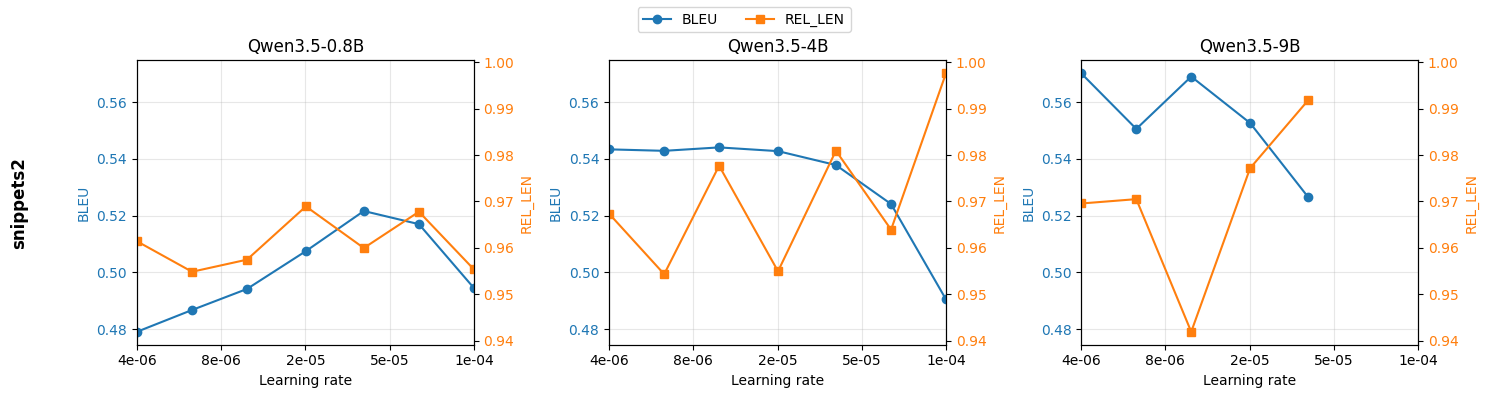

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
importlib.reload(collect_results)

plot_df = df[["user", "model", "learning_rate", "BLEU", "NUM_WORDS", "NUM_WORDS_GOLDEN"]].dropna().copy()
plot_df["REL_LEN"] = plot_df["NUM_WORDS"] / plot_df["NUM_WORDS_GOLDEN"].where(
    plot_df["NUM_WORDS_GOLDEN"] != 0
)

best_by_lr = (
    plot_df.loc[
        plot_df.groupby(["user", "model", "learning_rate"])["BLEU"].idxmax()
    ]
    .sort_values(["user", "model", "learning_rate"])
    .reset_index(drop=True)
)
summary = best_by_lr

if summary.empty:
    print("No rows available to plot.")
else:
    def padded_limits(values, pad_fraction=0.05):
        values = values.dropna()
        if values.empty:
            return None
        lower = values.min()
        upper = values.max()
        if lower == upper:
            pad = 1.0 if lower == 0 else abs(lower) * pad_fraction
        else:
            pad = (upper - lower) * pad_fraction
        return lower - pad, upper + pad

    users = sorted(summary["user"].unique())
    models = sorted(summary["model"].unique())
    bleu_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "BLEU"])
        for user in users
    }
    rel_len_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "REL_LEN"])
        for user in users
    }
    positive_learning_rates = summary.loc[summary["learning_rate"] > 0, "learning_rate"].dropna()
    learning_rate_limits = None
    learning_rate_ticks = None
    if not positive_learning_rates.empty:
        unique_learning_rates = np.sort(positive_learning_rates.unique())
        if len(unique_learning_rates) == 1:
            learning_rate_ticks = unique_learning_rates
            learning_rate_limits = (
                unique_learning_rates[0] / 10,
                unique_learning_rates[0] * 10,
            )
        else:
            learning_rate_limits = (
                unique_learning_rates.min(),
                unique_learning_rates.max(),
            )
            if len(unique_learning_rates) <= 5:
                learning_rate_ticks = unique_learning_rates
            else:
                learning_rate_ticks = np.geomspace(*learning_rate_limits, num=5)
    fig, axes = plt.subplots(
        len(users),
        len(models),
        figsize=(5 * len(models), 4 * len(users)),
        squeeze=False,
    )
    legend_lines = None

    for row_idx, user in enumerate(users):
        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            if row_idx == 0:
                ax.set_title(model)
            if col_idx == 0:
                ax.text(
                    -0.35,
                    0.5,
                    user,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            user_model_df = summary[
                (summary["user"] == user) & (summary["model"] == model)
            ]
            if user_model_df.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="0.5")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            ax_rel = ax.twinx()
            bleu_line = ax.plot(
                user_model_df["learning_rate"],
                user_model_df["BLEU"],
                marker="o",
                color="tab:blue",
                label="BLEU",
            )
            rel_len_line = ax_rel.plot(
                user_model_df["learning_rate"],
                user_model_df["REL_LEN"],
                marker="s",
                color="tab:orange",
                label="REL_LEN",
            )

            if legend_lines is None:
                legend_lines = bleu_line + rel_len_line

            ax.set_xlabel("Learning rate")
            ax.set_ylabel("BLEU", color="tab:blue")
            ax_rel.set_ylabel("REL_LEN", color="tab:orange")
            ax.tick_params(axis="y", labelcolor="tab:blue")
            ax_rel.tick_params(axis="y", labelcolor="tab:orange")
            if learning_rate_limits is not None:
                ax.set_xscale("log")
                ax.set_xlim(*learning_rate_limits)
                ax.set_xticks(learning_rate_ticks)
                ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0e"))
                ax.xaxis.set_minor_locator(mticker.NullLocator())
            if bleu_limits[user] is not None:
                ax.set_ylim(*bleu_limits[user])
            if rel_len_limits[user] is not None:
                ax_rel.set_ylim(*rel_len_limits[user])
            ax.grid(True, alpha=0.3)

    if legend_lines is not None:
        fig.legend(legend_lines, [line.get_label() for line in legend_lines], loc="upper center", ncol=2)

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


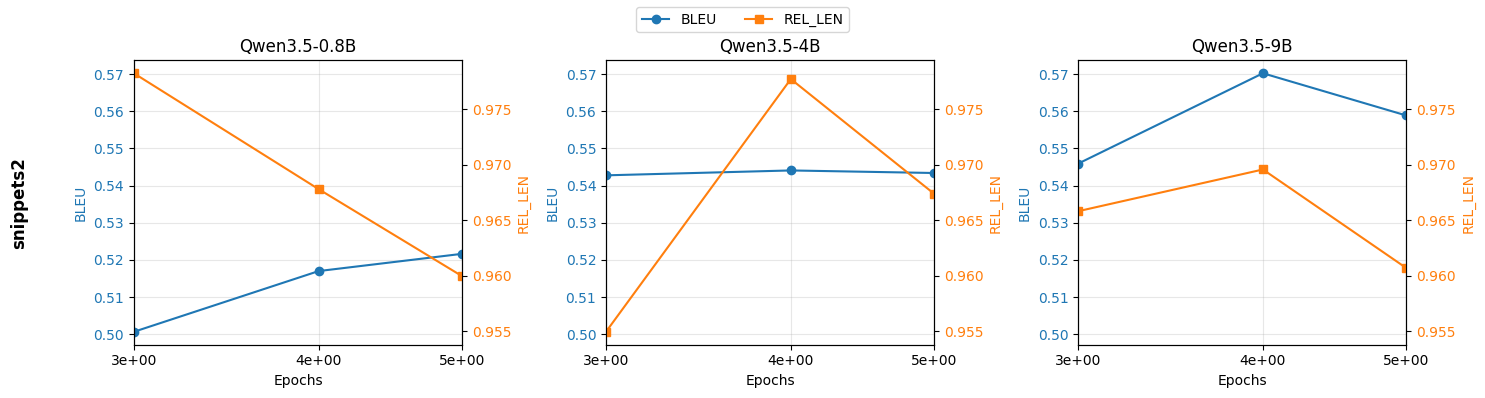

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
importlib.reload(collect_results)

plot_df = df[["user", "model", "epochs", "BLEU", "NUM_WORDS", "NUM_WORDS_GOLDEN"]].dropna().copy()
plot_df["REL_LEN"] = plot_df["NUM_WORDS"] / plot_df["NUM_WORDS_GOLDEN"].where(
    plot_df["NUM_WORDS_GOLDEN"] != 0
)

best_by_lr = (
    plot_df.loc[
        plot_df.groupby(["user", "model", "epochs"])["BLEU"].idxmax()
    ]
    .sort_values(["user", "model", "epochs"])
    .reset_index(drop=True)
)
summary = best_by_lr

if summary.empty:
    print("No rows available to plot.")
else:
    def padded_limits(values, pad_fraction=0.05):
        values = values.dropna()
        if values.empty:
            return None
        lower = values.min()
        upper = values.max()
        if lower == upper:
            pad = 1.0 if lower == 0 else abs(lower) * pad_fraction
        else:
            pad = (upper - lower) * pad_fraction
        return lower - pad, upper + pad

    users = sorted(summary["user"].unique())
    models = sorted(summary["model"].unique())
    bleu_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "BLEU"])
        for user in users
    }
    rel_len_limits = {
        user: padded_limits(summary.loc[summary["user"] == user, "REL_LEN"])
        for user in users
    }
    positive_learning_rates = summary.loc[summary["epochs"] > 0, "epochs"].dropna()
    learning_rate_limits = None
    learning_rate_ticks = None
    if not positive_learning_rates.empty:
        unique_learning_rates = np.sort(positive_learning_rates.unique())
        if len(unique_learning_rates) == 1:
            learning_rate_ticks = unique_learning_rates
            learning_rate_limits = (
                unique_learning_rates[0] / 10,
                unique_learning_rates[0] * 10,
            )
        else:
            learning_rate_limits = (
                unique_learning_rates.min(),
                unique_learning_rates.max(),
            )
            if len(unique_learning_rates) <= 5:
                learning_rate_ticks = unique_learning_rates
            else:
                learning_rate_ticks = np.geomspace(*learning_rate_limits, num=5)
    fig, axes = plt.subplots(
        len(users),
        len(models),
        figsize=(5 * len(models), 4 * len(users)),
        squeeze=False,
    )
    legend_lines = None

    for row_idx, user in enumerate(users):
        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            if row_idx == 0:
                ax.set_title(model)
            if col_idx == 0:
                ax.text(
                    -0.35,
                    0.5,
                    user,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center",
                    ha="center",
                    fontsize=12,
                    fontweight="bold",
                )

            user_model_df = summary[
                (summary["user"] == user) & (summary["model"] == model)
            ]
            if user_model_df.empty:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="0.5")
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            ax_rel = ax.twinx()
            bleu_line = ax.plot(
                user_model_df["epochs"],
                user_model_df["BLEU"],
                marker="o",
                color="tab:blue",
                label="BLEU",
            )
            rel_len_line = ax_rel.plot(
                user_model_df["epochs"],
                user_model_df["REL_LEN"],
                marker="s",
                color="tab:orange",
                label="REL_LEN",
            )

            if legend_lines is None:
                legend_lines = bleu_line + rel_len_line

            ax.set_xlabel("Epochs")
            ax.set_ylabel("BLEU", color="tab:blue")
            ax_rel.set_ylabel("REL_LEN", color="tab:orange")
            ax.tick_params(axis="y", labelcolor="tab:blue")
            ax_rel.tick_params(axis="y", labelcolor="tab:orange")
            if learning_rate_limits is not None:
                ax.set_xscale("log")
                ax.set_xlim(*learning_rate_limits)
                ax.set_xticks(learning_rate_ticks)
                ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0e"))
                ax.xaxis.set_minor_locator(mticker.NullLocator())
            if bleu_limits[user] is not None:
                ax.set_ylim(*bleu_limits[user])
            if rel_len_limits[user] is not None:
                ax_rel.set_ylim(*rel_len_limits[user])
            ax.grid(True, alpha=0.3)

    if legend_lines is not None:
        fig.legend(legend_lines, [line.get_label() for line in legend_lines], loc="upper center", ncol=2)

    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


In [28]:
df.sort_values(by="BLEU", ascending=False, inplace=True)
df[df.model == "Qwen3.5-4B"][["batch_size", "learning_rate", "epochs", "BLEU", "run_name"]]

,batch_size,learning_rate,epochs,BLEU,run_name
7,8,0.000011,4,0.544052,panza_snippets2-Qwen3.5-4B-bf16-bs8-fft-lr1.1e...
8,4,0.000004,5,0.543362,panza_snippets2-Qwen3.5-4B-bf16-bs4-fft-lr3.6e...
9,16,0.000006,5,0.542842,panza_snippets2-Qwen3.5-4B-bf16-bs16-fft-lr6.3...
10,16,0.000020,3,0.542735,panza_snippets2-Qwen3.5-4B-bf16-bs16-fft-lr2e-...
11,8,0.000004,4,0.542027,panza_snippets2-Qwen3.5-4B-bf16-bs8-fft-lr3.6e...
...,...,...,...,...,...
128,8,0.000110,3,0.402843,panza_snippets2-Qwen3.5-4B-bf16-bs8-fft-lr0.00...
130,4,0.000110,5,0.367829,panza_snippets2-Qwen3.5-4B-bf16-bs4-fft-lr0.00...
131,4,0.000063,4,0.356497,panza_snippets2-Qwen3.5-4B-bf16-bs4-fft-lr6.3e...
134,4,0.000110,4,0.302549,panza_snippets2-Qwen3.5-4B-bf16-bs4-fft-lr0.00...


In [7]:
run_counts = (
    df.groupby(["user", "model", "batch_size", "epochs"], dropna=False)
    .size()
    .reset_index(name="num_runs")
    .sort_values(["user", "model", "batch_size", "epochs"])
    .reset_index(drop=True)
)

run_counts[run_counts.user == 'isabel']


,user,model,batch_size,epochs,num_runs
66,isabel,Llama-3.2-1B-Instruct,4,4,15
67,isabel,Llama-3.2-1B-Instruct,4,5,24
68,isabel,Llama-3.2-1B-Instruct,4,7,9
69,isabel,Llama-3.2-1B-Instruct,8,4,15
70,isabel,Llama-3.2-1B-Instruct,8,5,24
...,...,...,...,...,...
126,isabel,Qwen3.5-9B,8,7,9
127,isabel,Qwen3.5-9B,8,9,24
128,isabel,Qwen3.5-9B,16,4,15
129,isabel,Qwen3.5-9B,16,5,24
